In [1]:
# imports
import pickle
import os
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d as spline

import morph_analyses as m

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
# make some null priors
sigma_likelihood=.3
x=np.linspace(-.3,1.3,num=1000)[np.newaxis,:]


# uniform

uniform_prior = np.ones(x.shape)/x.size
uniform_post = uniform_prior*m.utilities.gaussian(x.T,sigma_likelihood,x)
uniform_post = uniform_post/uniform_post.sum(axis=1,keepdims=True)

# gaussian
gaussian_prior = m.utilities.gaussian(.5,.2,x)
gaussian_post = gaussian_prior*m.utilities.gaussian(x.T,sigma_likelihood,x)
gaussian_post = gaussian_post/gaussian_post.sum(axis=1,keepdims=True)


# multimodal prior
mf_prior = 0
for _m,w in zip([0,.25,.5,.75,1.],[1,1,10,1,1]):
   
    mf_prior += w*m.utilities.gaussian(_m,.08,x)
mf_post = mf_prior*m.utilities.gaussian(x.T,sigma_likelihood,x)
mf_post = mf_post/mf_post.sum(axis=1,keepdims=True)

flat_post = np.ones(uniform_post.shape)
flat_post = flat_post/flat_post.sum(axis=1,keepdims=True)

In [3]:

with open(m.params.data_dir / "morph_hists.pkl", 'rb') as file:
    morph_dict = pickle.load(file)
    
rare_dists = m.empirical_priors.prior_post(morph_dict['rare'])
freq_dists = m.empirical_priors.prior_post(morph_dict['frequent'])

rare_prior = rare_dists['combined_wallmorph_prior']
freq_prior = freq_dists['combined_wallmorph_prior']

rare_post = rare_dists['wallmorph_posterior']
freq_post = freq_dists['wallmorph_posterior']

Text(0.5, 1.0, '$P(f_h|\\hat{S})$')

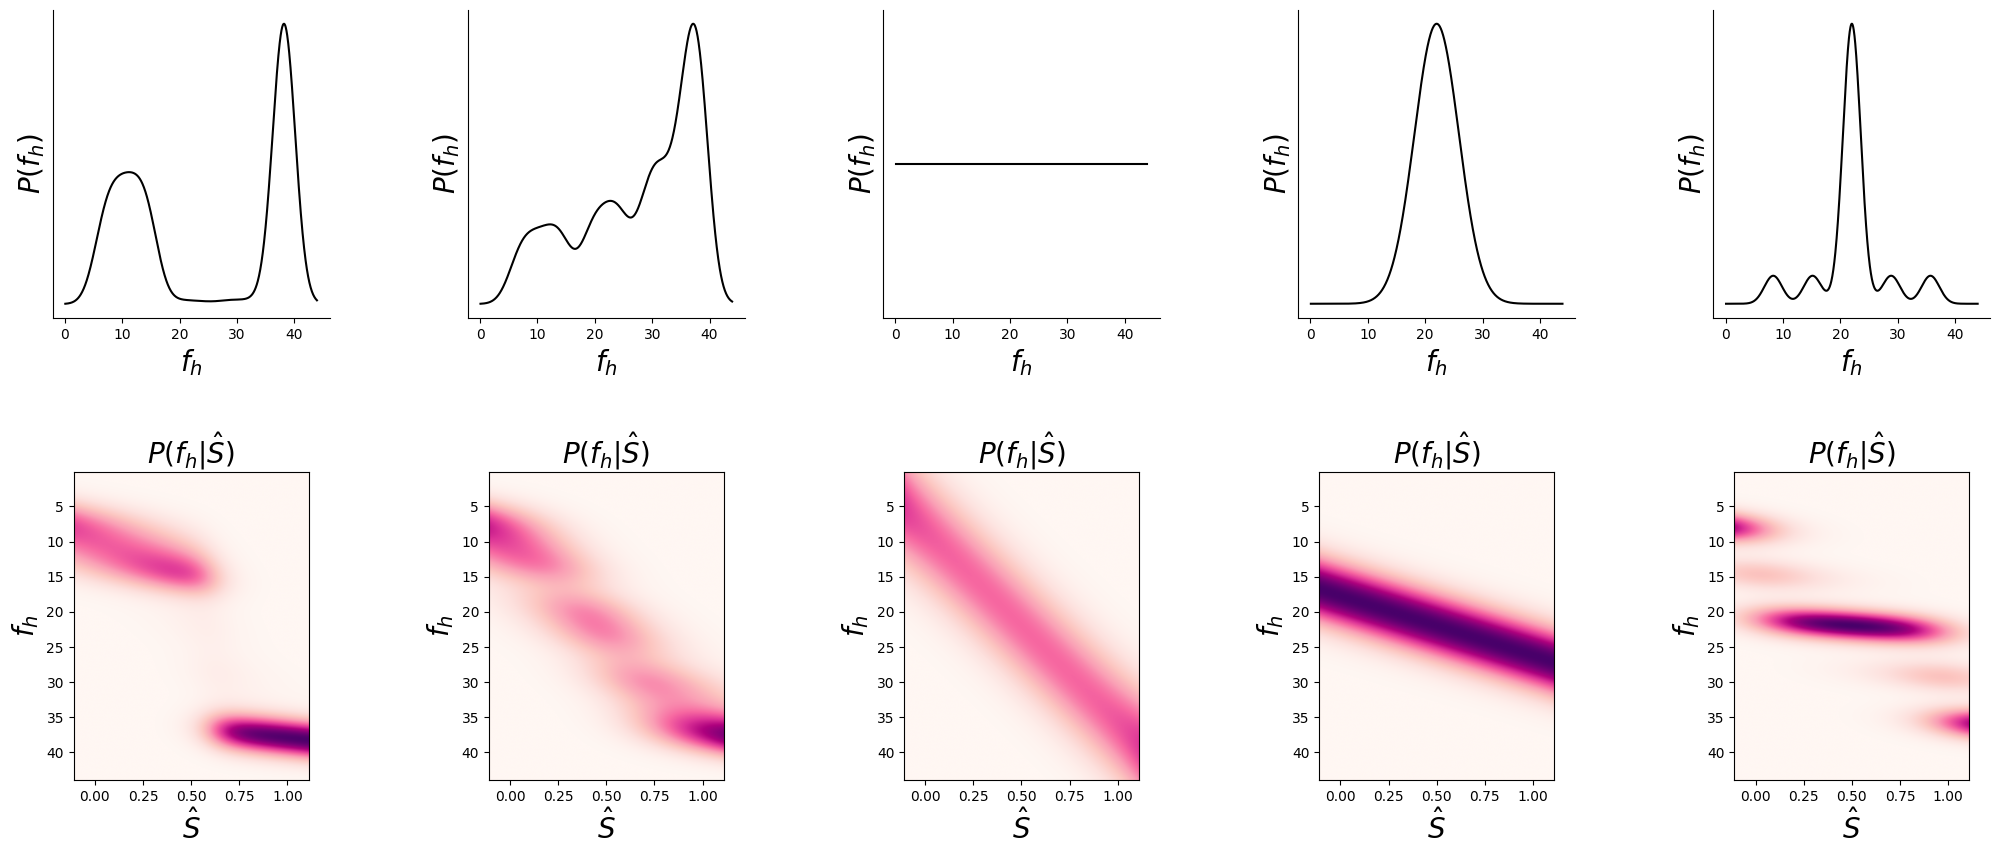

In [4]:
low,high = m.unity_transforms.inv_wallmorphx(-.3),m.unity_transforms.inv_wallmorphx(1.3)

f,ax = plt.subplots(2,5,figsize=[25,10])
f.subplots_adjust(wspace=.5,hspace=.5)

ax[0,0].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),rare_prior.ravel(),color='black')
ax[0,0].set_xlabel("$f_{h}$",fontsize=20)
ax[0,0].set_ylabel("$P(f_h)$",fontsize=20)
ax[0,0].set_yticks([])
ax[0,0].spines['top'].set_visible(False)
ax[0,0].spines['right'].set_visible(False)


ax[1,0].imshow(rare_post.T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(rare_post,20),aspect=(1.6)/(high-low))
ax[1,0].set_xlim([-.11,1.11])
ax[1,0].set_xlabel("$\hat{S}$",fontsize=20)
ax[1,0].set_ylabel("$f_{h}$",fontsize=20)
ax[1,0].set_title("$P(f_h|\hat{S})$",fontsize=20)


ax[0,1].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),freq_prior.ravel(),color='black')
ax[0,1].set_xlabel("$f_{h}$",fontsize=20)
ax[0,1].set_ylabel("$P(f_h)$",fontsize=20)
ax[0,1].set_yticks([])
ax[0,1].spines['top'].set_visible(False)
ax[0,1].spines['right'].set_visible(False)


ax[1,1].imshow(freq_post.T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(freq_post,20),aspect=(1.6)/(high-low))
ax[1,1].set_xlim([-.11,1.11])
ax[1,1].set_xlabel("$\hat{S}$",fontsize=20)
ax[1,1].set_ylabel("$f_{h}$",fontsize=20)
ax[1,1].set_title("$P(f_h|\hat{S})$",fontsize=20)

ax[0,2].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),uniform_prior.ravel(),color='black')
ax[0,2].set_xlabel("$f_{h}$",fontsize=20)
ax[0,2].set_ylabel("$P(f_h)$",fontsize=20)
ax[0,2].set_yticks([])
ax[0,2].spines['top'].set_visible(False)
ax[0,2].spines['right'].set_visible(False)


ax[1,2].imshow(uniform_post.T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(uniform_post,20),aspect=(1.6)/(high-low))
ax[1,2].set_xlim([-.11,1.11])
ax[1,2].set_xlabel("$\hat{S}$",fontsize=20)
ax[1,2].set_ylabel("$f_{h}$",fontsize=20)
ax[1,2].set_title("$P(f_h|\hat{S})$",fontsize=20)


ax[0,3].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),gaussian_prior.ravel(),color='black')
ax[0,3].set_xlabel("$f_{h}$",fontsize=20)
ax[0,3].set_ylabel("$P(f_h)$",fontsize=20)
ax[0,3].set_yticks([])
ax[0,3].spines['top'].set_visible(False)
ax[0,3].spines['right'].set_visible(False)


ax[1,3].imshow(gaussian_post.T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(gaussian_post,20),aspect=(1.6)/(high-low))
ax[1,3].set_xlim([-.11,1.11])
ax[1,3].set_xlabel("$\hat{S}$",fontsize=20)
ax[1,3].set_ylabel("$f_{h}$",fontsize=20)
ax[1,3].set_title("$P(f_h|\hat{S})$",fontsize=20)


ax[0,4].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),mf_prior.ravel(),color='black')
ax[0,4].set_xlabel("$f_{h}$",fontsize=20)
ax[0,4].set_ylabel("$P(f_h)$",fontsize=20)
ax[0,4].set_yticks([])
ax[0,4].spines['top'].set_visible(False)
ax[0,4].spines['right'].set_visible(False)


ax[1,4].imshow(mf_post.T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(mf_post,20),aspect=(1.6)/(high-low))
ax[1,4].set_xlim([-.11,1.11])
ax[1,4].set_xlabel("$\hat{S}$",fontsize=20)
ax[1,4].set_ylabel("$f_{h}$",fontsize=20)
ax[1,4].set_title("$P(f_h|\hat{S})$",fontsize=20)

Text(0, 0.5, '$f_h$')

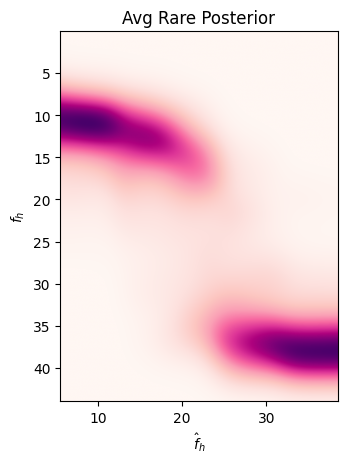

In [5]:
rare_avgH, rare_dkl = m.similarity_fraction.get_kl_div_summary(m.mouse_metadata.rare_sessions, morph_dict=morph_dict)

x = np.linspace(-.3,1.3,num=1000)
mask = (x>=.1) * (x<=1.1)
fig, ax = plt.subplots()
extent = [
    m.unity_transforms.inv_wallmorphx(-.1),
    m.unity_transforms.inv_wallmorphx(1.1),
    m.unity_transforms.inv_wallmorphx(1.3),
    m.unity_transforms.inv_wallmorphx(-.3)
    ]
ax.imshow(rare_avgH[mask,:].T,cmap='RdPu',extent=extent)
ax.set_title(r"Avg Rare Posterior" )
ax.set_xlabel("$\hat{f}_h$")
ax.set_ylabel("$f_h$")

Text(0, 0.5, '$f_h$')

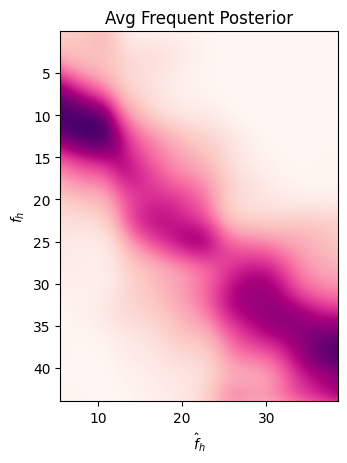

In [6]:
freq_avgH, freq_dkl = m.similarity_fraction.get_kl_div_summary(m.mouse_metadata.frequent_sessions, morph_dict=morph_dict)

x = np.linspace(-.3,1.3,num=1000)
mask = (x>=.1) * (x<=1.1)
fig, ax = plt.subplots()
extent = [
    m.unity_transforms.inv_wallmorphx(-.1),
    m.unity_transforms.inv_wallmorphx(1.1),
    m.unity_transforms.inv_wallmorphx(1.3),
    m.unity_transforms.inv_wallmorphx(-.3)
    ]
ax.imshow(freq_avgH[mask,:].T,cmap='RdPu',extent=extent)
ax.set_title(r"Avg Frequent Posterior" )
ax.set_xlabel("$\hat{f}_h$")
ax.set_ylabel("$f_h$")

In [7]:
def get_null_kl(H):
    x = np.linspace(-.3,1.3,num=1000)
    rare_kl,freq_kl,uniform_kl,gaussian_kl,mf_kl,flat_kl = [],[],[],[],[],[]
    for row in range(H.shape[1]):
        if (x[row]>=.1) and (x[row]<=1.1):
            rare_kl.append(sp.stats.entropy(rare_post[row,:],H[row,:],base=2))
            freq_kl.append(sp.stats.entropy(freq_post[row,:],H[row,:],base=2))
            uniform_kl.append(sp.stats.entropy(uniform_post[row,:],H[row,:],base=2))
            gaussian_kl.append(sp.stats.entropy(gaussian_post[row,:],H[row,:],base=2))
            mf_kl.append(sp.stats.entropy(mf_post[row,:],H[row,:],base=2))
            flat_kl.append(sp.stats.entropy(flat_post[row,:],H[row,:],base=2))
    rare_kl,freq_kl,uniform_kl,gaussian_kl,mf_kl,flat_kl= np.array(rare_kl),np.array(freq_kl),np.array(uniform_kl),np.array(gaussian_kl),np.array(mf_kl),np.array(flat_kl)
    return [rare_kl.mean(),freq_kl.mean(),uniform_kl.mean(),gaussian_kl.mean(),mf_kl.mean(),flat_kl.mean()]



def null_model_kl_divs(sessions, trial_mat_key='spks_norm'):
    H = 0
    dkl = {}
    for mouse, metadata in sessions.items():
        sess_list = metadata['test_sessions']
        
        if len(sess_list)==0:
            continue
        
        dkl[mouse] = []
        for i, sess_deets in enumerate(sess_list):
            sess = m.sess.CA1MorphSession.from_nwb(mouse, 'testing', sess_deets['day'])
            wallmorph = m.unity_transforms.wallmorphx(sess.trial_info['effective_morph'])
            trial_mat = sess.trial_matrices[trial_mat_key]
            trial_mat[np.isnan(trial_mat)]=0
            
            sf = m.utilities.similarity_fraction(trial_mat, sess.trial_info)
            yhat = m.similarity_fraction.sf_to_yhat(sf, sess.trial_info['morphs'])
            
            H, _ = m.similarity_fraction.single_session_kldiv(wallmorph, yhat, morph_dict=morph_dict)
            
            
            dkl[mouse].append(get_null_kl(H))
            
        
        
    return dkl

In [8]:
rare_null_dkls = null_model_kl_divs(m.mouse_metadata.rare_sessions)

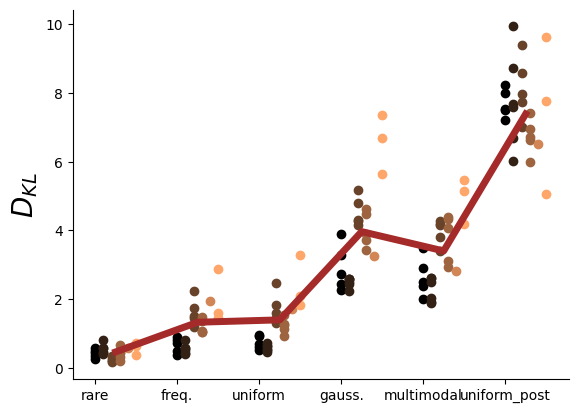

In [9]:
f,ax = plt.subplots()
avg_kl = 0
for i,(mouse, kl) in enumerate(rare_null_dkls.items()):
    kl = np.array(kl)
    avg_kl += kl.mean(axis=0)
    ax.scatter(np.arange(6)[np.newaxis,:]*np.ones([kl.shape[0],1])+.1*i,kl,color=plt.cm.copper(float(i)/len(m.mouse_metadata.rare_mice)))
    
avg_kl /= i+1
ax.plot(np.arange(6)+.1*i/2,avg_kl,color='brown',linewidth='5')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("$D_{KL}$",fontsize=20)

ax.set_xticks(np.arange(6), labels = ['rare', 'freq.', 'uniform', 'gauss.', 'multimodal', 'uniform_post'])


In [10]:
freq_null_dkls = null_model_kl_divs(m.mouse_metadata.frequent_sessions)


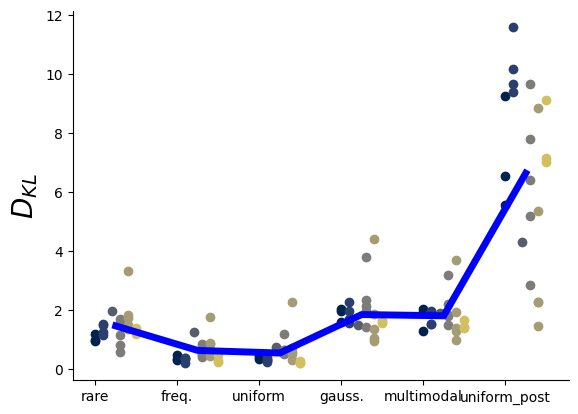

In [11]:
f,ax = plt.subplots()
avg_kl = 0
for i,(mouse, kl) in enumerate(freq_null_dkls.items()):
    kl = np.array(kl)
    avg_kl += kl.mean(axis=0)
    ax.scatter(np.arange(6)[np.newaxis,:]*np.ones([kl.shape[0],1])+.1*i,kl,color=plt.cm.cividis(float(i)/len(m.mouse_metadata.frequent_mice)))
    
avg_kl /= i+1
ax.plot(np.arange(6)+.1*i/2,avg_kl,color='blue',linewidth='5')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("$D_{KL}$",fontsize=20)

ax.set_xticks(np.arange(6), labels = ['rare', 'freq.', 'uniform', 'gauss.', 'multimodal', 'uniform_post'])

In [13]:



def null_prior_kl_divs(sessions, cmap, trial_mat_key='spks_norm'):
    f,ax = plt.subplots(1,2)
    
    x = np.linspace(-.3,1.3,num=1000)
    
    for mouse, metadata in sessions.items():
        sess_list = metadata['test_sessions']
        
        if len(sess_list)==0:
            continue
        
        wallmorph, yhat = [], []
        for i, sess_deets in enumerate(sess_list):
            sess = m.sess.CA1MorphSession.from_nwb(mouse, 'testing', sess_deets['day'])
            wallmorph.append(m.unity_transforms.wallmorphx(sess.trial_info['effective_morph']))
            trial_mat = sess.trial_matrices[trial_mat_key]
            trial_mat[np.isnan(trial_mat)]=0
            
            sf = m.utilities.similarity_fraction(trial_mat, sess.trial_info)
            yhat.append(m.similarity_fraction.sf_to_yhat(sf, sess.trial_info['morphs']))
        
        wallmorph = np.concatenate(wallmorph)
        yhat = np.concatenate(yhat)
        
        wmsm = m.utilities.gaussian(wallmorph[:,np.newaxis,np.newaxis],.1,x[np.newaxis,:,np.newaxis])
        yhsm = m.utilities.gaussian(yhat[:,np.newaxis,np.newaxis],.1,x[np.newaxis,np.newaxis,:])
        H = np.sum(wmsm*yhsm,axis=0)
        Z = H.sum(axis=1)
        H/=H.sum(axis=1,keepdims=True)
        H_prior =H.sum(axis=0)/(m.utilities.gaussian(x,sigma_likelihood,x[:,np.newaxis])/Z[:,np.newaxis]).sum(axis=1)
        H_prior /= H_prior.sum()
        
        rarekl = sp.stats.entropy(rare_prior.ravel(), H_prior,base=2)
        freqkl = sp.stats.entropy(freq_prior.ravel(), H_prior,base=2)
        uniformkl = sp.stats.entropy(uniform_prior.ravel(), H_prior,base=2)
        gaussiankl = sp.stats.entropy(gaussian_prior.ravel(), H_prior,base=2)
        mfkl = sp.stats.entropy(mf_prior.ravel(), H_prior,base=2)
        
        
        ax[0].plot(m.unity_transforms.inv_wallmorphx(x), H_prior, color=cmap(float(i/len(sessions.keys()))))
        ax[1].scatter(np.arange(5)+i*.05,[rarekl,freqkl,uniformkl,gaussiankl,mfkl],color =cmap(float(i/len(sessions.keys()))))
        
        
    f.subplots_adjust(wspace=.5)
    ax[0].set_yticks([])
    ax[0].set_ylabel("$P(f_h)$",fontsize=15)
    ax[0].set_xlabel("$f_h$",fontsize=15)
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)

    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].set_ylabel("$D_{KL}$",fontsize=15)
    
    ax[1].set_xticks(np.arange(5), labels = ['rare', 'freq.', 'uniform', 'gauss.', 'multimodal'])
    return f, ax

            

(<Figure size 640x480 with 2 Axes>,
 array([<Axes: xlabel='$f_h$', ylabel='$P(f_h)$'>,
        <Axes: ylabel='$D_{KL}$'>], dtype=object))

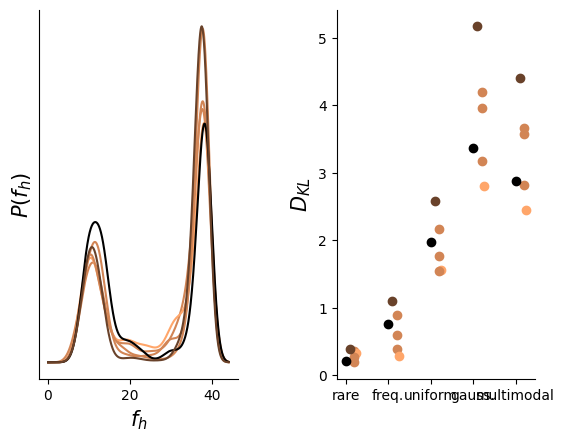

In [14]:
null_prior_kl_divs(m.mouse_metadata.rare_sessions, plt.get_cmap('copper'))

(<Figure size 640x480 with 2 Axes>,
 array([<Axes: xlabel='$f_h$', ylabel='$P(f_h)$'>,
        <Axes: ylabel='$D_{KL}$'>], dtype=object))

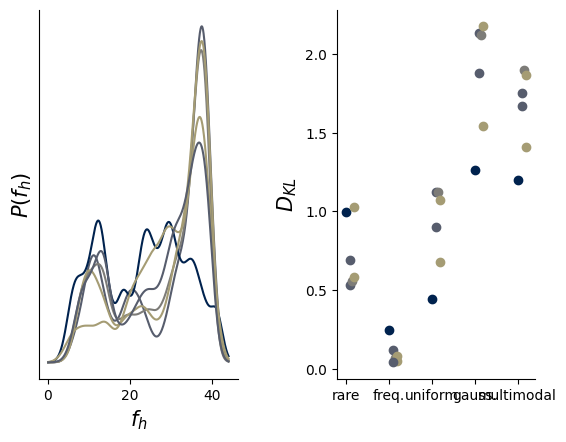

In [15]:
null_prior_kl_divs(m.mouse_metadata.frequent_sessions, plt.get_cmap('cividis'))